In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)
import random
import optuna
import torch.optim as optim
import time

# Data

In [2]:
df = pd.read_csv('./data/prepared_data_mill13.csv')
df['average_time'] = pd.to_datetime(df['average_time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values(by='average_time')
df = df.reset_index(drop=True)
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850


In [3]:
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
INITIAL_BAUXITE = 7 # исходное количество боксита в мельнице, т

# Параметры для расчета объема пульпы в мельнице
FILL_RATE = 0.45  # доля заполнения мельницы
BALL_MASS = 60  # масса мелящих шаров, т
MILL_VOLUME = 36  # объем мельницы, м3
MILL_LENGTH = 4.5 # длина мельницы, м
STEEL_DENSITY = 7800  # плотность стали, кг/м3
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
WATER_DENSITY = 1000 # плотность воды, кг/м3

# -- Для Розина-Раммлера --
D1 = 0.056 # диаметр сита, мм
D2 = 0.16 # диаметр сита, мм

# объём шаров, м3
BALL_VOLUME = BALL_MASS * 1000 / STEEL_DENSITY

# Объём пульпы (боксит+вода+раствор), м3
SLURRY_VOLUME = MILL_VOLUME * FILL_RATE - BALL_VOLUME

# Площадь сечения мельницы, м2
MILL_AREA =  MILL_VOLUME / MILL_LENGTH

# Площадь сечения пульпы, м2
F_SLURRY = SLURRY_VOLUME / MILL_LENGTH

# epsilon для вычисления скорости
EPS = 1-(BALL_VOLUME/MILL_VOLUME)

# Вычисление v

In [4]:
import numpy as np

def mean_filter(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')


df['Qsolid_[m3/h]'] = df['Q_bauxite_[t/h]'] * 0.9 * 1000 / BAUXITE_DENSITY 
df['Qliquid_[m3/h]'] = (df['Q_bauxite_[t/h]'] * 0.1 * 1000 / WATER_DENSITY) + df['Q_liquid_mill13_[m3/h]'] # Вычисление жидкой составляющей
df['V_[m/s]'] = EPS * (df['Qsolid_[m3/h]']+df['Qliquid_[m3/h]']) / (F_SLURRY * 3600)
df['residence_time_[s]'] = MILL_LENGTH / df['V_[m/s]']

# MEAN FILTER
df['mean_S_[m2/kg]'] = mean_filter(df['S_[m2/kg]'].to_numpy(), window_size=7)

df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349


In [5]:
df.describe()

,Unnamed: 0,Q_bauxite_[t/h],Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
count,177.000000,175.000000,177.000000,177.000000,177.000000,177.000000,177,177.000000,177.000000,177.000000,177.000000,175.000000,175.000000,175.000000,175.000000,177.000000
mean,88.576271,69.851291,49.660452,3.594915,20.679322,62.604463,2023-05-21 08:08:14.915254,0.626045,0.793207,0.085557,248.561597,22.452201,56.532558,0.009125,499.172780,247.262246
min,0.000000,29.085400,31.600000,1.300000,3.910000,17.470000,2023-01-03 08:42:30,0.174700,0.502000,0.016907,6.138922,9.348879,41.733030,0.006635,354.862422,77.045933
25%,44.000000,57.169150,46.800000,2.900000,15.790000,57.710000,2023-03-20 11:19:00,0.577100,0.746600,0.039683,158.777292,18.375798,53.403010,0.008412,463.296897,202.627966
50%,88.000000,68.048500,49.400000,3.500000,20.120000,63.390000,2023-04-28 13:43:30,0.633900,0.798800,0.055416,222.177075,21.872732,56.370570,0.009064,496.463547,245.048961
75%,134.000000,80.149450,52.100000,4.200000,25.340000,69.030000,2023-06-20 11:44:30,0.690300,0.842100,0.077543,310.261934,25.762323,59.328130,0.009713,534.957322,289.023029
max,178.000000,155.165900,69.900000,6.600000,49.800000,82.400000,2023-12-09 17:15:00,0.824000,0.960900,2.005580,728.239346,49.874754,72.494390,0.012681,678.200077,367.370992
std,51.950655,18.000133,5.099289,0.847675,7.443997,10.182559,NaN,0.101826,0.074440,0.176219,137.937491,5.785757,5.125208,0.001018,55.141431,61.026551


In [6]:
6 / (2800 * 4 / 1000)

0.5357142857142857

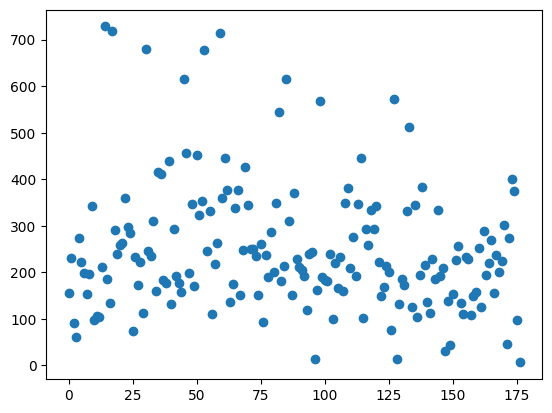

In [7]:
plt.scatter(range(len(df)), df["S_[m2/kg]"])
plt.show()

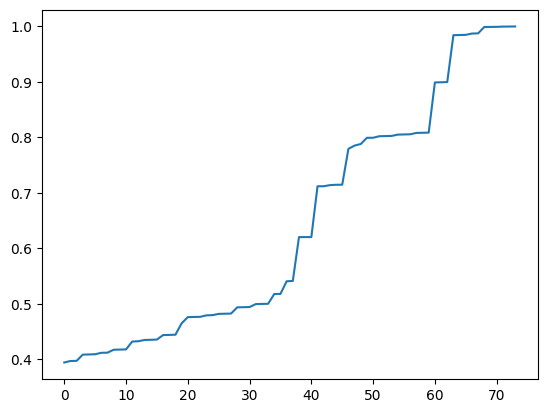

In [20]:
plt.plot(data['t_bc1_test'])

## Генерация датасета

In [8]:
data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "S_bc1_train": [],
    "v_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "S_bc2_train": [],
    "v_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "S_bc1_test": [],
    "v_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "S_bc2_test": [],
    "v_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    'S_ic_test': [],
}

s_in = 0.5 #m2/kg боксит на входе в мельницу
z_max = 4.5 / 4.5
n_pde = 30
s_0 = 10 #m2/kg боксит вов ремя начала работы мельницы
t_max = (df['average_time'][len(df)-1] - df['average_time'][0]).total_seconds()

# --- Генерация тренировочных данных ---
for i, row in df[:101].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        t = row['average_time'] - df['average_time'][0] # 
        t = t.total_seconds() / t_max # seconds
        v = row['V_[m/s]'] # / 0.012681
        # s = row['S_[m2/kg]'] # / 728.239346
        s = row['mean_S_[m2/kg]']
        
        # -- Начало мельницы ---
        data['t_bc1_train'].append(t)
        data['z_bc1_train'].append(0)
        data['v_bc1_train'].append(v)
        data['S_bc1_train'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_train'].append(t)
        data['z_bc2_train'].append(z_max)
        data['v_bc2_train'].append(v)
        data['S_bc2_train'].append(s)

        # -- Initinal condition
        data['t_ic_train'].append(0)
        data['z_ic_train'].append(z_max)
        data['v_ic_train'].append(v)
        data['S_ic_train'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_train'].append(t)
            data['z_pde_train'].append(random.random()*z_max)
            data['v_pde_train'].append(v)

# --- Генерация тестовых данных ---
for i, row in df[101:].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        t = row['average_time'] - df['average_time'][0] 
        t = t.total_seconds() / t_max # seconds
        v = row['V_[m/s]'] # / 0.012681
        # s = row['S_[m2/kg]'] # / 728.239346
        s = row['mean_S_[m2/kg]']
        
        # -- Начало мельницы ---
        data['t_bc1_test'].append(t)
        data['z_bc1_test'].append(0)
        data['v_bc1_test'].append(v)
        data['S_bc1_test'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_test'].append(t)
        data['z_bc2_test'].append(z_max)
        data['v_bc2_test'].append(v)
        data['S_bc2_test'].append(s)

        # -- initinal --
        data['t_ic_test'].append(0)
        data['z_ic_test'].append(z_max)
        data['v_ic_test'].append(v)
        data['S_ic_test'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_test'].append(t)
            data['z_pde_test'].append(random.random()*z_max)
            data['v_pde_test'].append(v)

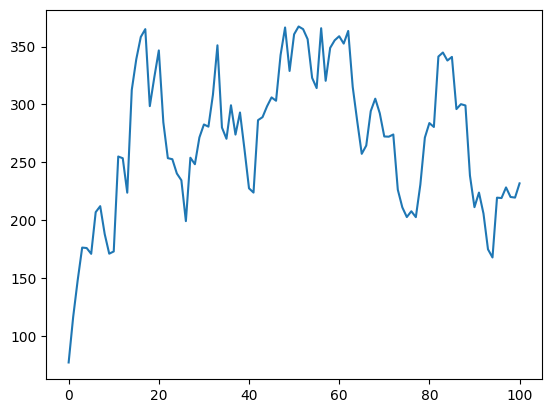

In [9]:
plt.plot(data['S_bc2_train'])

# Преобразование в нужный для PINN вид

In [11]:
from loss.pinn_loss_v2 import pinn_loss_v2
from networks.PINN_v2 import PINN_v2

In [12]:
t_data = torch.tensor(df["residence_time_[s]"].values, dtype=torch.float32).reshape(-1, 1)
z_data = torch.ones(len(df),1)
v_data = torch.tensor(df["V_[m/s]"].values, dtype=torch.float32).reshape(-1, 1)
S_true = torch.tensor(df["S_[m2/kg]"].values, dtype=torch.float32).reshape(-1, 1)

In [ ]:
# model = PINN_v2(k=3e-3)
# model = PINN_v2(k=0.2674744507660731)

optimizer = optim.Adam(model.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(50_000):
    model.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        model,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=1.0, 
        lambda_bc1=1.0, 
        lambda_bc2=3.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-'*20)
    


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
PDE: 1.454 | BC1: 0.041 | BC2: 327.905
Epoch 0 | Loss: 329.400 | k = 0.26747
PDE: 0.169 | BC1: 0.000 | BC2: 167.529
Epoch 100 | Loss: 167.699 | k = 0.26747
PDE: 0.219 | BC1: 0.001 | BC2: 167.395
Epoch 200 | Loss: 167.614 | k = 0.26747
PDE: 0.160 | BC1: 0.000 | BC2: 164.445
Epoch 300 | Loss: 164.605 | k = 0.26747
PDE: 0.157 | BC1: 0.000 | BC2: 161.384
Epoch 400 | Loss: 161.541 | k = 0.26747
PDE: 0.175 | BC1: 0.000 | BC2: 160.036
Epoch 500 | Loss: 160.212 | k = 0.26747
PDE: 0.217 | BC1: 0.000 | BC2: 158.698
Epoch 600 | Loss: 158.915 | k = 0.26747
PDE: 0.145 | BC1: 0.000 | BC2: 158.491
Epoch 700 | Loss: 158.637 | k = 0.26747
PDE: 0.141 | BC1: 0.000 | BC2: 156.302
Epoch 800 | Loss: 156.443 | k = 0.26747
PDE: 0.241 | BC1: 0.000 | BC2: 154.040
Epoch 900 | Loss: 154.281 | k = 0.26747
PDE: 0.184 | BC1: 0.000 | BC2: 152.240
Epoch 1000 | Loss: 152.423 | k = 0.26747
PDE: 0.290 | BC1: 0.000 | BC2: 151.117
Epoch 1100 | Loss: 151.407 | k = 0.26747
PDE: 0.209 |

KeyboardInterrupt: 

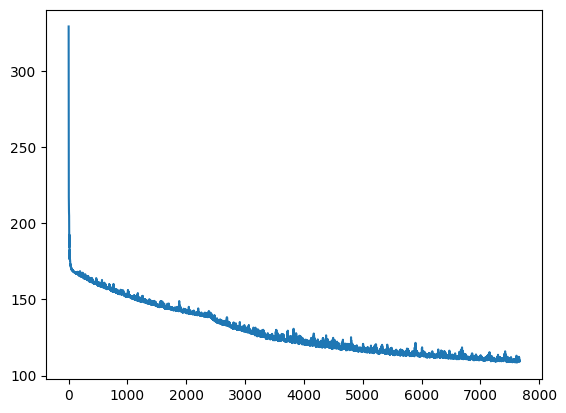

In [34]:
plt.plot(history)

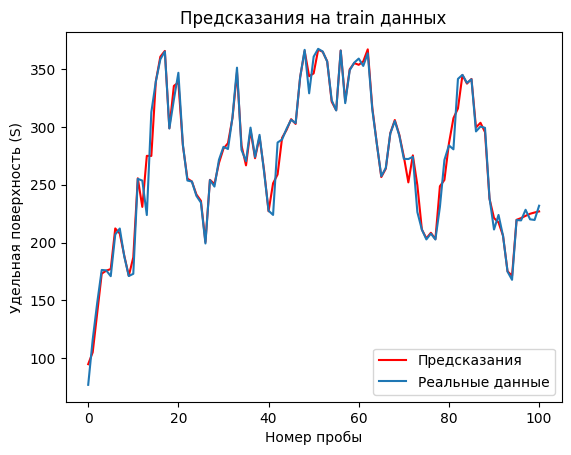

In [30]:
plt.plot(model(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

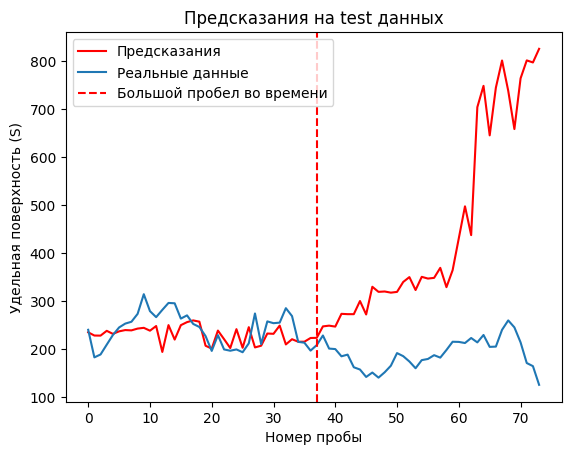

In [32]:
plt.plot(model(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [ ]:
model(
    torch.tensor([0]).reshape(-1, 1),
    torch.tensor([4.5]).reshape(-1, 1),
    torch.tensor([0.008409]).reshape(-1, 1)
)

tensor([[-2.7074]], grad_fn=<AddmmBackward0>)

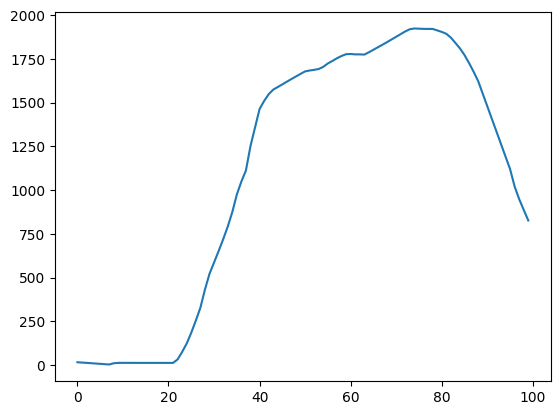

In [33]:
n = 100
i = -1
pred = list(
    model(
        torch.tensor([data["t_bc1_test"][i]] * n, dtype=torch.float32).reshape(-1, 1),
        (torch.tensor(np.linspace(0, 1, n), dtype=torch.float32)*z_max).reshape(-1, 1),
        torch.tensor([data["v_bc1_test"][i]] * n, dtype=torch.float32).reshape(-1, 1),
        ).reshape(-1).detach().numpy()
        )

plt.plot(pred)

In [19]:
5e-4

0.0005

# Оптимизация k

R2

In [ ]:
def objective(trial):
    k = trial.suggest_float('k', 5e-4, 3e-3)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(50_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем R^2
    r2_1 = r2_score(
        torch.tensor(data["S_bc1_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred1.detach().numpy()
        )
    r2_2 = r2_score(
        torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred2.detach().numpy()
        )

    # Берем среднее
    r2 = np.mean([r2_1,r2_2])

    return r2

In [11]:
study = optuna.create_study(study_name="find_optimal_k", direction="maximize")

[I 2026-05-22 16:23:34,148] A new study created in memory with name: find_optimal_k


5e-4, 3e-3

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 359469678592.000 | k = 0.003
Epoch 100 | Loss: 157995.422 | k = 0.003
Epoch 200 | Loss: 5022851.500 | k = 0.003
Epoch 300 | Loss: 68945664.000 | k = 0.003
Epoch 400 | Loss: 106484.797 | k = 0.003
Epoch 500 | Loss: 100467.352 | k = 0.003
Epoch 600 | Loss: 95713.797 | k = 0.003
Epoch 700 | Loss: 95699.094 | k = 0.003
Epoch 800 | Loss: 95688.062 | k = 0.003
Epoch 900 | Loss: 95678.312 | k = 0.003
Epoch 1000 | Loss: 95664.000 | k = 0.003
Epoch 1100 | Loss: 95653.125 | k = 0.003
Epoch 1200 | Loss: 95640.094 | k = 0.003
Epoch 1300 | Loss: 95625.156 | k = 0.003
Epoch 1400 | Loss: 95607.422 | k = 0.003
Epoch 1500 | Loss: 95590.656 | k = 0.003
Epoch 1600 | Loss: 95572.664 | k = 0.003
Epoch 1700 | Loss: 95553.812 | k = 0.003
Epoch 1800 | Loss: 95531.070 | k = 0.003
Epoch 1900 | Loss: 95509.922 | k = 0.003
Epoch 2000 | Loss: 95488.938 | k = 0.003
Epoch 2100 | Loss: 95462.805 | k = 0.003
Epoch 2200 | Loss: 95436.219 | k = 0.003
Epoch 2300 | L

[I 2026-05-22 16:29:29,522] Trial 0 finished with value: -0.013924002647399902 and parameters: {'k': 0.0025801687266729495}. Best is trial 0 with value: -0.013924002647399902.


Лучший k: 0.0025801687266729495
Лучший R^2: -0.013924002647399902
Время выполнения поиска оптимального параметра: 350.12 секунд


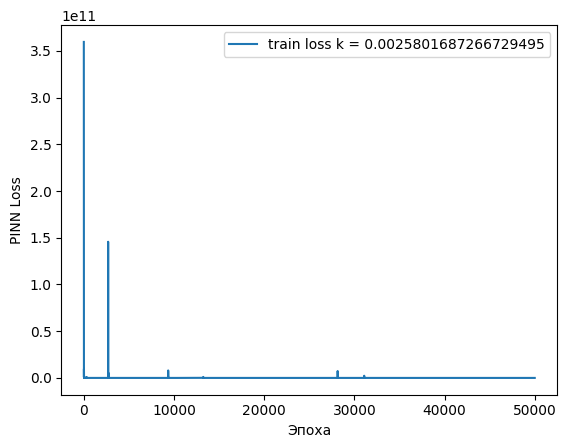

In [12]:
start_time = time.time()
study.optimize(objective, n_trials=1) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

4e-3, 1

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 313214369792.000 | k = 0.944
Epoch 100 | Loss: 888979.625 | k = 0.944
Epoch 200 | Loss: 84203968.000 | k = 0.944
Epoch 300 | Loss: 21205014.000 | k = 0.944
Epoch 400 | Loss: 355898.438 | k = 0.944
Epoch 500 | Loss: 600248.250 | k = 0.944
Epoch 600 | Loss: 347295.719 | k = 0.944
Epoch 700 | Loss: 347232.375 | k = 0.944
Epoch 800 | Loss: 347176.250 | k = 0.944
Epoch 900 | Loss: 27945200.000 | k = 0.944
Epoch 1000 | Loss: 4394654.500 | k = 0.944
Epoch 1100 | Loss: 21870494.000 | k = 0.944
Epoch 1200 | Loss: 348060.688 | k = 0.944
Epoch 1300 | Loss: 347409.531 | k = 0.944
Epoch 1400 | Loss: 54968944.000 | k = 0.944
Epoch 1500 | Loss: 349633.562 | k = 0.944
Epoch 1600 | Loss: 1646405.750 | k = 0.944
Epoch 1700 | Loss: 13323244.000 | k = 0.944
Epoch 1800 | Loss: 28881564.000 | k = 0.944
Epoch 1900 | Loss: 347950.438 | k = 0.944
Epoch 2000 | Loss: 346742.469 | k = 0.944
Epoch 2100 | Loss: 346389.812 | k = 0.944
Epoch 2200 | Loss: 472090.

[I 2026-05-22 01:31:35,071] Trial 0 finished with value: -0.46906954050064087 and parameters: {'k': 0.9435990536881762}. Best is trial 0 with value: -0.46906954050064087.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 5033860096.000 | k = 0.097
Epoch 100 | Loss: 2552777.250 | k = 0.097
Epoch 200 | Loss: 234627.953 | k = 0.097
Epoch 300 | Loss: 3982101.750 | k = 0.097
Epoch 400 | Loss: 640097.688 | k = 0.097
Epoch 500 | Loss: 188601.656 | k = 0.097
Epoch 600 | Loss: 102433.641 | k = 0.097
Epoch 700 | Loss: 98705.375 | k = 0.097
Epoch 800 | Loss: 98688.500 | k = 0.097
Epoch 900 | Loss: 98673.547 | k = 0.097
Epoch 1000 | Loss: 98653.312 | k = 0.097
Epoch 1100 | Loss: 98637.609 | k = 0.097
Epoch 1200 | Loss: 98611.766 | k = 0.097
Epoch 1300 | Loss: 98593.797 | k = 0.097
Epoch 1400 | Loss: 98574.195 | k = 0.097
Epoch 1500 | Loss: 98544.562 | k = 0.097
Epoch 1600 | Loss: 98517.109 | k = 0.097
Epoch 1700 | Loss: 98486.938 | k = 0.097
Epoch 1800 | Loss: 98456.719 | k = 0.097
Epoch 1900 | Loss: 98424.258 | k = 0.097
Epoch 2000 | Loss: 98390.812 | k = 0.097
Epoch 2100 | Loss: 466475.781 | k = 0.097
Epoch 2200 | Loss: 99536.461 | k = 0.097
Epoch 2300 | Lo

[I 2026-05-22 01:34:50,827] Trial 1 finished with value: -0.011344969272613525 and parameters: {'k': 0.09699490943001722}. Best is trial 1 with value: -0.011344969272613525.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 100744511488.000 | k = 0.358
Epoch 100 | Loss: 168382.266 | k = 0.358
Epoch 200 | Loss: 1743023.500 | k = 0.358
Epoch 300 | Loss: 53906984.000 | k = 0.358
Epoch 400 | Loss: 315937.250 | k = 0.358
Epoch 500 | Loss: 140675.188 | k = 0.358
Epoch 600 | Loss: 138069.656 | k = 0.358
Epoch 700 | Loss: 138049.406 | k = 0.358
Epoch 800 | Loss: 138026.906 | k = 0.358
Epoch 900 | Loss: 138003.766 | k = 0.358
Epoch 1000 | Loss: 137976.203 | k = 0.358
Epoch 1100 | Loss: 5015716.000 | k = 0.358
Epoch 1200 | Loss: 138581.625 | k = 0.358
Epoch 1300 | Loss: 138554.250 | k = 0.358
Epoch 1400 | Loss: 358760.250 | k = 0.358
Epoch 1500 | Loss: 8320702.000 | k = 0.358
Epoch 1600 | Loss: 138645.891 | k = 0.358
Epoch 1700 | Loss: 138517.156 | k = 0.358
Epoch 1800 | Loss: 8481241.000 | k = 0.358
Epoch 1900 | Loss: 146008.375 | k = 0.358
Epoch 2000 | Loss: 138468.094 | k = 0.358
Epoch 2100 | Loss: 138427.125 | k = 0.358
Epoch 2200 | Loss: 205503184.000 | k

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 9300056064.000 | k = 0.838
Epoch 100 | Loss: 13169798.000 | k = 0.838
Epoch 200 | Loss: 16557856.000 | k = 0.838
Epoch 300 | Loss: 8341835.500 | k = 0.838
Epoch 400 | Loss: 439029.938 | k = 0.838
Epoch 500 | Loss: 301877.656 | k = 0.838
Epoch 600 | Loss: 301847.281 | k = 0.838
Epoch 700 | Loss: 301820.406 | k = 0.838
Epoch 800 | Loss: 301788.562 | k = 0.838
Epoch 900 | Loss: 2255670.000 | k = 0.838
Epoch 1000 | Loss: 302682.594 | k = 0.838
Epoch 1100 | Loss: 302228.812 | k = 0.838
Epoch 1200 | Loss: 1432523264.000 | k = 0.838
Epoch 1300 | Loss: 323747.062 | k = 0.838
Epoch 1400 | Loss: 303526.844 | k = 0.838
Epoch 1500 | Loss: 302138.906 | k = 0.838
Epoch 1600 | Loss: 302548.188 | k = 0.838
Epoch 1700 | Loss: 301518.344 | k = 0.838
Epoch 1800 | Loss: 403868.875 | k = 0.838
Epoch 1900 | Loss: 300789.875 | k = 0.838
Epoch 2000 | Loss: 307039.875 | k = 0.838
Epoch 2100 | Loss: 305752.562 | k = 0.838
Epoch 2200 | Loss: 300020.875 | k 

[I 2026-05-22 01:57:59,116] Trial 8 finished with value: -13.645926475524902 and parameters: {'k': 0.8380420495300945}. Best is trial 2 with value: -0.0010154247283935547.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 294353024.000 | k = 0.369
Epoch 100 | Loss: 61186248.000 | k = 0.369
Epoch 200 | Loss: 3731895.500 | k = 0.369
Epoch 300 | Loss: 381160.625 | k = 0.369
Epoch 400 | Loss: 1179014.500 | k = 0.369
Epoch 500 | Loss: 141195.797 | k = 0.369
Epoch 600 | Loss: 141163.266 | k = 0.369
Epoch 700 | Loss: 141151.984 | k = 0.369
Epoch 800 | Loss: 141140.312 | k = 0.369
Epoch 900 | Loss: 141127.609 | k = 0.369
Epoch 1000 | Loss: 141113.484 | k = 0.369
Epoch 1100 | Loss: 66560632.000 | k = 0.369
Epoch 1200 | Loss: 141837.812 | k = 0.369
Epoch 1300 | Loss: 141318.125 | k = 0.369
Epoch 1400 | Loss: 141936.125 | k = 0.369
Epoch 1500 | Loss: 146717.859 | k = 0.369
Epoch 1600 | Loss: 141202.969 | k = 0.369
Epoch 1700 | Loss: 141170.188 | k = 0.369
Epoch 1800 | Loss: 141077.500 | k = 0.369
Epoch 1900 | Loss: 140998.297 | k = 0.369
Epoch 2000 | Loss: 140931.547 | k = 0.369
Epoch 2100 | Loss: 140879.922 | k = 0.369
Epoch 2200 | Loss: 1763581.500 | k = 0.

[I 2026-05-22 02:01:13,642] Trial 9 finished with value: -4.783960819244385 and parameters: {'k': 0.36868141836046014}. Best is trial 2 with value: -0.0010154247283935547.


Лучший k: 0.35767177647639864
Лучший R^2: -0.0010154247283935547
Время выполнения поиска оптимального параметра: 1974.83 секунд


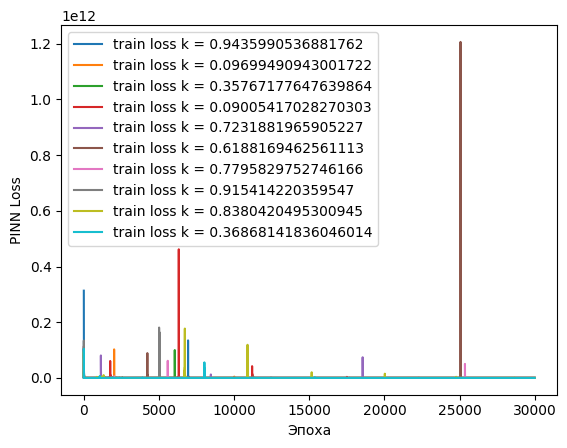

In [33]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

0.01, 1

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 45532344320.000 | k = 0.056
Epoch 100 | Loss: 1273346.500 | k = 0.056
Epoch 200 | Loss: 202970.703 | k = 0.056
Epoch 300 | Loss: 280384.812 | k = 0.056
Epoch 400 | Loss: 1464620.875 | k = 0.056
Epoch 500 | Loss: 132946.109 | k = 0.056
Epoch 600 | Loss: 149188.234 | k = 0.056
Epoch 700 | Loss: 98862.703 | k = 0.056
Epoch 800 | Loss: 97379.117 | k = 0.056
Epoch 900 | Loss: 97370.125 | k = 0.056
Epoch 1000 | Loss: 97360.406 | k = 0.056
Epoch 1100 | Loss: 97353.391 | k = 0.056
Epoch 1200 | Loss: 97342.969 | k = 0.056
Epoch 1300 | Loss: 97333.109 | k = 0.056
Epoch 1400 | Loss: 97323.484 | k = 0.056
Epoch 1500 | Loss: 97313.594 | k = 0.056
Epoch 1600 | Loss: 97299.828 | k = 0.056
Epoch 1700 | Loss: 97288.719 | k = 0.056
Epoch 1800 | Loss: 97273.336 | k = 0.056
Epoch 1900 | Loss: 97260.562 | k = 0.056
Epoch 2000 | Loss: 97247.758 | k = 0.056
Epoch 2100 | Loss: 97231.922 | k = 0.056
Epoch 2200 | Loss: 97216.672 | k = 0.056
Epoch 2300 | Lo

[I 2026-05-22 02:13:50,126] Trial 0 finished with value: -1.504765510559082 and parameters: {'k': 0.05564832364328041}. Best is trial 0 with value: -1.504765510559082.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 1358325504.000 | k = 0.771
Epoch 100 | Loss: 276099.562 | k = 0.771
Epoch 200 | Loss: 5800840.500 | k = 0.771
Epoch 300 | Loss: 10349791.000 | k = 0.771
Epoch 400 | Loss: 57725248.000 | k = 0.771
Epoch 500 | Loss: 5460680.000 | k = 0.771
Epoch 600 | Loss: 273621.938 | k = 0.771
Epoch 700 | Loss: 273585.188 | k = 0.771
Epoch 800 | Loss: 273555.094 | k = 0.771
Epoch 900 | Loss: 6003919.500 | k = 0.771
Epoch 1000 | Loss: 561379.375 | k = 0.771
Epoch 1100 | Loss: 545327.438 | k = 0.771
Epoch 1200 | Loss: 273835.219 | k = 0.771
Epoch 1300 | Loss: 273763.812 | k = 0.771
Epoch 1400 | Loss: 273674.656 | k = 0.771
Epoch 1500 | Loss: 273565.281 | k = 0.771
Epoch 1600 | Loss: 273418.844 | k = 0.771
Epoch 1700 | Loss: 273234.219 | k = 0.771
Epoch 1800 | Loss: 273007.031 | k = 0.771
Epoch 1900 | Loss: 1597566.875 | k = 0.771
Epoch 2000 | Loss: 278213.625 | k = 0.771
Epoch 2100 | Loss: 273245.594 | k = 0.771
Epoch 2200 | Loss: 273052.656 | k = 

[I 2026-05-22 02:17:06,423] Trial 1 finished with value: -1.8519172668457031 and parameters: {'k': 0.7712311546580839}. Best is trial 0 with value: -1.504765510559082.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 38606094336.000 | k = 0.801
Epoch 100 | Loss: 685405.938 | k = 0.801
Epoch 200 | Loss: 1666426.375 | k = 0.801
Epoch 300 | Loss: 759770.000 | k = 0.801
Epoch 400 | Loss: 612074.250 | k = 0.801
Epoch 500 | Loss: 286438.719 | k = 0.801
Epoch 600 | Loss: 286398.406 | k = 0.801
Epoch 700 | Loss: 286372.375 | k = 0.801
Epoch 800 | Loss: 286338.094 | k = 0.801
Epoch 900 | Loss: 286302.531 | k = 0.801
Epoch 1000 | Loss: 288038.000 | k = 0.801
Epoch 1100 | Loss: 286392.469 | k = 0.801
Epoch 1200 | Loss: 286344.438 | k = 0.801
Epoch 1300 | Loss: 286271.344 | k = 0.801
Epoch 1400 | Loss: 2701730.500 | k = 0.801
Epoch 1500 | Loss: 312512.031 | k = 0.801
Epoch 1600 | Loss: 285861.625 | k = 0.801
Epoch 1700 | Loss: 285613.094 | k = 0.801
Epoch 1800 | Loss: 2439233.750 | k = 0.801
Epoch 1900 | Loss: 285118.219 | k = 0.801
Epoch 2000 | Loss: 284769.312 | k = 0.801
Epoch 2100 | Loss: 288708.562 | k = 0.801
Epoch 2200 | Loss: 237987760.000 | k = 0

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 80010543104.000 | k = 0.372
Epoch 100 | Loss: 56706128.000 | k = 0.372
Epoch 200 | Loss: 207049.422 | k = 0.372
Epoch 300 | Loss: 6174890.500 | k = 0.372
Epoch 400 | Loss: 24420746.000 | k = 0.372
Epoch 500 | Loss: 141489.703 | k = 0.372
Epoch 600 | Loss: 600053.875 | k = 0.372
Epoch 700 | Loss: 141245.562 | k = 0.372
Epoch 800 | Loss: 141209.156 | k = 0.372
Epoch 900 | Loss: 141196.500 | k = 0.372
Epoch 1000 | Loss: 141174.719 | k = 0.372
Epoch 1100 | Loss: 141158.125 | k = 0.372
Epoch 1200 | Loss: 141136.281 | k = 0.372
Epoch 1300 | Loss: 141115.750 | k = 0.372
Epoch 1400 | Loss: 141096.562 | k = 0.372
Epoch 1500 | Loss: 141073.906 | k = 0.372
Epoch 1600 | Loss: 141050.500 | k = 0.372
Epoch 1700 | Loss: 141026.172 | k = 0.372
Epoch 1800 | Loss: 141001.234 | k = 0.372
Epoch 1900 | Loss: 140974.656 | k = 0.372
Epoch 2000 | Loss: 140945.750 | k = 0.372
Epoch 2100 | Loss: 321078.531 | k = 0.372
Epoch 2200 | Loss: 142108.734 | k = 0.

[I 2026-05-22 02:39:47,777] Trial 8 finished with value: -0.0019254088401794434 and parameters: {'k': 0.37161674963531854}. Best is trial 8 with value: -0.0019254088401794434.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 143868493824.000 | k = 0.853
Epoch 100 | Loss: 22630308.000 | k = 0.853
Epoch 200 | Loss: 1572927.750 | k = 0.853
Epoch 300 | Loss: 813462.062 | k = 0.853
Epoch 400 | Loss: 836139.250 | k = 0.853
Epoch 500 | Loss: 308311.625 | k = 0.853
Epoch 600 | Loss: 308258.688 | k = 0.853
Epoch 700 | Loss: 308230.375 | k = 0.853
Epoch 800 | Loss: 308206.844 | k = 0.853
Epoch 900 | Loss: 308170.594 | k = 0.853
Epoch 1000 | Loss: 308133.812 | k = 0.853
Epoch 1100 | Loss: 308090.062 | k = 0.853
Epoch 1200 | Loss: 3568184.000 | k = 0.853
Epoch 1300 | Loss: 309064.344 | k = 0.853
Epoch 1400 | Loss: 317339.031 | k = 0.853
Epoch 1500 | Loss: 308657.594 | k = 0.853
Epoch 1600 | Loss: 308593.812 | k = 0.853
Epoch 1700 | Loss: 308511.906 | k = 0.853
Epoch 1800 | Loss: 308398.562 | k = 0.853
Epoch 1900 | Loss: 659620.625 | k = 0.853
Epoch 2000 | Loss: 308025.781 | k = 0.853
Epoch 2100 | Loss: 24483460.000 | k = 0.853
Epoch 2200 | Loss: 308050.000 | k = 

[I 2026-05-22 02:42:59,211] Trial 9 finished with value: -0.34117400646209717 and parameters: {'k': 0.8532489620836924}. Best is trial 8 with value: -0.0019254088401794434.


Лучший k: 0.37161674963531854
Лучший R^2: -0.0019254088401794434
Время выполнения поиска оптимального параметра: 1946.79 секунд


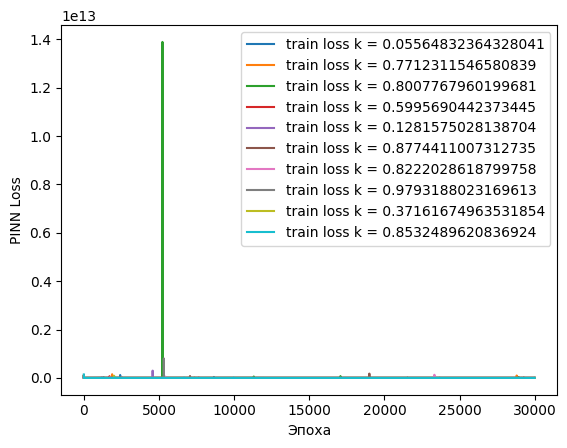

In [36]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

0, 5

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 20751675392.000 | k = 0.894
Epoch 100 | Loss: 1035190.125 | k = 0.894
Epoch 200 | Loss: 11499917.000 | k = 0.894
Epoch 300 | Loss: 16244512.000 | k = 0.894
Epoch 400 | Loss: 7098599.000 | k = 0.894
Epoch 500 | Loss: 390018.250 | k = 0.894
Epoch 600 | Loss: 324553.125 | k = 0.894
Epoch 700 | Loss: 324514.812 | k = 0.894
Epoch 800 | Loss: 324468.344 | k = 0.894
Epoch 900 | Loss: 784039.000 | k = 0.894
Epoch 1000 | Loss: 325500.438 | k = 0.894
Epoch 1100 | Loss: 325675.656 | k = 0.894
Epoch 1200 | Loss: 3626716.500 | k = 0.894
Epoch 1300 | Loss: 438467264.000 | k = 0.894
Epoch 1400 | Loss: 53345600.000 | k = 0.894
Epoch 1500 | Loss: 4009123.500 | k = 0.894
Epoch 1600 | Loss: 383765.688 | k = 0.894
Epoch 1700 | Loss: 325498.844 | k = 0.894
Epoch 1800 | Loss: 325231.969 | k = 0.894
Epoch 1900 | Loss: 324919.969 | k = 0.894
Epoch 2000 | Loss: 324581.312 | k = 0.894
Epoch 2100 | Loss: 324249.375 | k = 0.894
Epoch 2200 | Loss: 1589471.250

[I 2026-05-22 02:52:42,935] Trial 0 finished with value: -0.7007180452346802 and parameters: {'k': 0.8935148790107206}. Best is trial 0 with value: -0.7007180452346802.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 8171719680.000 | k = 3.290
Epoch 100 | Loss: 4804148.500 | k = 3.290
Epoch 200 | Loss: 1785356.000 | k = 3.290
Epoch 300 | Loss: 1728459.125 | k = 3.290
Epoch 400 | Loss: 1631177.000 | k = 3.290
Epoch 500 | Loss: 1597626.000 | k = 3.290
Epoch 600 | Loss: 10677777.000 | k = 3.290
Epoch 700 | Loss: 44769164.000 | k = 3.290
Epoch 800 | Loss: 1592082.500 | k = 3.290
Epoch 900 | Loss: 1585797.000 | k = 3.290
Epoch 1000 | Loss: 1585644.625 | k = 3.290
Epoch 1100 | Loss: 1585476.000 | k = 3.290
Epoch 1200 | Loss: 1585300.750 | k = 3.290
Epoch 1300 | Loss: 1585075.000 | k = 3.290
Epoch 1400 | Loss: 1584843.250 | k = 3.290
Epoch 1500 | Loss: 1584599.750 | k = 3.290
Epoch 1600 | Loss: 1584291.875 | k = 3.290
Epoch 1700 | Loss: 1583954.125 | k = 3.290
Epoch 1800 | Loss: 1583528.000 | k = 3.290
Epoch 1900 | Loss: 1582867.000 | k = 3.290
Epoch 2000 | Loss: 1581931.750 | k = 3.290
Epoch 2100 | Loss: 1580595.500 | k = 3.290
Epoch 2200 | Loss: 15

[I 2026-05-22 02:55:58,808] Trial 1 finished with value: -81.6447525024414 and parameters: {'k': 3.2900882300030387}. Best is trial 0 with value: -0.7007180452346802.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 208564158464.000 | k = 4.028
Epoch 100 | Loss: 4435567.500 | k = 4.028
Epoch 200 | Loss: 2613751.500 | k = 4.028
Epoch 300 | Loss: 10302457.000 | k = 4.028
Epoch 400 | Loss: 7103512.000 | k = 4.028
Epoch 500 | Loss: 2152857.250 | k = 4.028
Epoch 600 | Loss: 2074249.250 | k = 4.028
Epoch 700 | Loss: 2071404.750 | k = 4.028
Epoch 800 | Loss: 2071220.500 | k = 4.028
Epoch 900 | Loss: 3271189248.000 | k = 4.028
Epoch 1000 | Loss: 2155784.750 | k = 4.028
Epoch 1100 | Loss: 2073541.375 | k = 4.028
Epoch 1200 | Loss: 2073741.875 | k = 4.028
Epoch 1300 | Loss: 2073270.875 | k = 4.028
Epoch 1400 | Loss: 2073155.250 | k = 4.028
Epoch 1500 | Loss: 2073023.250 | k = 4.028
Epoch 1600 | Loss: 2072867.750 | k = 4.028
Epoch 1700 | Loss: 2072713.625 | k = 4.028
Epoch 1800 | Loss: 2080245.125 | k = 4.028
Epoch 1900 | Loss: 2072357.750 | k = 4.028
Epoch 2000 | Loss: 2072146.250 | k = 4.028
Epoch 2100 | Loss: 2071905.875 | k = 4.028
Epoch 2200 | Loss

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 23105300480.000 | k = 3.238
Epoch 100 | Loss: 4546861.000 | k = 3.238
Epoch 200 | Loss: 10098442.000 | k = 3.238
Epoch 300 | Loss: 3506650112.000 | k = 3.238
Epoch 400 | Loss: 23656696.000 | k = 3.238
Epoch 500 | Loss: 1558559.875 | k = 3.238
Epoch 600 | Loss: 1554647.250 | k = 3.238
Epoch 700 | Loss: 1554508.000 | k = 3.238
Epoch 800 | Loss: 36079896.000 | k = 3.238
Epoch 900 | Loss: 1555861.375 | k = 3.238
Epoch 1000 | Loss: 1556458.000 | k = 3.238
Epoch 1100 | Loss: 1553806.000 | k = 3.238
Epoch 1200 | Loss: 1854256.375 | k = 3.238
Epoch 1300 | Loss: 1553026.000 | k = 3.238
Epoch 1400 | Loss: 1552491.875 | k = 3.238
Epoch 1500 | Loss: 1551906.125 | k = 3.238
Epoch 1600 | Loss: 1551226.250 | k = 3.238
Epoch 1700 | Loss: 2896616.500 | k = 3.238
Epoch 1800 | Loss: 1550605.875 | k = 3.238
Epoch 1900 | Loss: 1549667.250 | k = 3.238
Epoch 2000 | Loss: 1548770.625 | k = 3.238
Epoch 2100 | Loss: 1547872.750 | k = 3.238
Epoch 2200 | Los

[I 2026-05-22 03:18:07,705] Trial 8 finished with value: -79.88156127929688 and parameters: {'k': 3.2379857218070676}. Best is trial 6 with value: -0.00020688772201538086.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 53068890112.000 | k = 0.748
Epoch 100 | Loss: 104430896.000 | k = 0.748
Epoch 200 | Loss: 6055741.500 | k = 0.748
Epoch 300 | Loss: 3481862.000 | k = 0.748
Epoch 400 | Loss: 338675.312 | k = 0.748
Epoch 500 | Loss: 364701.000 | k = 0.748
Epoch 600 | Loss: 264199.812 | k = 0.748
Epoch 700 | Loss: 264173.156 | k = 0.748
Epoch 800 | Loss: 264147.188 | k = 0.748
Epoch 900 | Loss: 264115.844 | k = 0.748
Epoch 1000 | Loss: 264080.781 | k = 0.748
Epoch 1100 | Loss: 264041.812 | k = 0.748
Epoch 1200 | Loss: 199369056.000 | k = 0.748
Epoch 1300 | Loss: 1094026.375 | k = 0.748
Epoch 1400 | Loss: 265160.688 | k = 0.748
Epoch 1500 | Loss: 331203.125 | k = 0.748
Epoch 1600 | Loss: 265012.219 | k = 0.748
Epoch 1700 | Loss: 264929.281 | k = 0.748
Epoch 1800 | Loss: 264824.969 | k = 0.748
Epoch 1900 | Loss: 264691.250 | k = 0.748
Epoch 2000 | Loss: 264521.750 | k = 0.748
Epoch 2100 | Loss: 264316.375 | k = 0.748
Epoch 2200 | Loss: 279243.812 | k 

[I 2026-05-22 03:21:21,935] Trial 9 finished with value: -1.4742021560668945 and parameters: {'k': 0.747755027717224}. Best is trial 6 with value: -0.00020688772201538086.


Лучший k: 0.33466800302734523
Лучший R^2: -0.00020688772201538086
Время выполнения поиска оптимального параметра: 1914.32 секунд


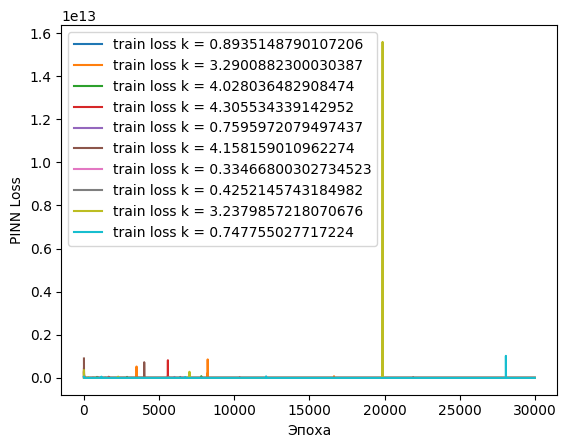

In [39]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 42950205440.000 | k = 0.001
Epoch 100 | Loss: 421410.062 | k = 0.001
Epoch 200 | Loss: 69763416.000 | k = 0.001
Epoch 300 | Loss: 96487.336 | k = 0.001
Epoch 400 | Loss: 1320808.250 | k = 0.001
Epoch 500 | Loss: 96390.523 | k = 0.001
Epoch 600 | Loss: 96387.547 | k = 0.001
Epoch 700 | Loss: 96384.969 | k = 0.001
Epoch 800 | Loss: 96384.047 | k = 0.001
Epoch 900 | Loss: 415951.312 | k = 0.001
Epoch 1000 | Loss: 25040882.000 | k = 0.001
Epoch 1100 | Loss: 103449.875 | k = 0.001
Epoch 1200 | Loss: 96384.977 | k = 0.001
Epoch 1300 | Loss: 96380.422 | k = 0.001
Epoch 1400 | Loss: 119617.172 | k = 0.001
Epoch 1500 | Loss: 1328037.750 | k = 0.001
Epoch 1600 | Loss: 96388.242 | k = 0.001
Epoch 1700 | Loss: 96383.141 | k = 0.001
Epoch 1800 | Loss: 96375.305 | k = 0.001
Epoch 1900 | Loss: 64058376.000 | k = 0.001
Epoch 2000 | Loss: 104070.688 | k = 0.001
Epoch 2100 | Loss: 96370.125 | k = 0.001
Epoch 2200 | Loss: 96367.836 | k = 0.001
Epoch

[I 2026-05-22 03:30:56,605] Trial 0 finished with value: -0.013925135135650635 and parameters: {'k': 0.0011277830958028427}. Best is trial 0 with value: -0.013925135135650635.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 122918338560.000 | k = 0.003
Epoch 100 | Loss: 7190263.000 | k = 0.003
Epoch 200 | Loss: 115875.523 | k = 0.003
Epoch 300 | Loss: 96279.016 | k = 0.003
Epoch 400 | Loss: 96278.578 | k = 0.003
Epoch 500 | Loss: 852274.375 | k = 0.003
Epoch 600 | Loss: 115415.344 | k = 0.003
Epoch 700 | Loss: 97000.586 | k = 0.003
Epoch 800 | Loss: 96284.734 | k = 0.003
Epoch 900 | Loss: 96284.062 | k = 0.003
Epoch 1000 | Loss: 96282.578 | k = 0.003
Epoch 1100 | Loss: 246741.156 | k = 0.003
Epoch 1200 | Loss: 96883.250 | k = 0.003
Epoch 1300 | Loss: 96283.766 | k = 0.003
Epoch 1400 | Loss: 190546.391 | k = 0.003
Epoch 1500 | Loss: 31206498.000 | k = 0.003
Epoch 1600 | Loss: 123804.656 | k = 0.003
Epoch 1700 | Loss: 495139.375 | k = 0.003
Epoch 1800 | Loss: 135416.688 | k = 0.003
Epoch 1900 | Loss: 96226.062 | k = 0.003
Epoch 2000 | Loss: 96250.086 | k = 0.003
Epoch 2100 | Loss: 136818.922 | k = 0.003
Epoch 2200 | Loss: 96233.656 | k = 0.003
Epoch 23

[I 2026-05-22 03:36:19,270] Trial 1 finished with value: -0.013923883438110352 and parameters: {'k': 0.0026255626857001188}. Best is trial 1 with value: -0.013923883438110352.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 1553816448.000 | k = 0.001
Epoch 100 | Loss: 120446.719 | k = 0.001
Epoch 200 | Loss: 7112046.000 | k = 0.001
Epoch 300 | Loss: 166979.516 | k = 0.001
Epoch 400 | Loss: 343340.125 | k = 0.001
Epoch 500 | Loss: 96301.688 | k = 0.001
Epoch 600 | Loss: 96958.648 | k = 0.001
Epoch 700 | Loss: 96294.938 | k = 0.001
Epoch 800 | Loss: 96295.336 | k = 0.001
Epoch 900 | Loss: 96293.758 | k = 0.001
Epoch 1000 | Loss: 96291.672 | k = 0.001
Epoch 1100 | Loss: 1126388.625 | k = 0.001
Epoch 1200 | Loss: 96335.875 | k = 0.001
Epoch 1300 | Loss: 96287.438 | k = 0.001
Epoch 1400 | Loss: 267532512.000 | k = 0.001
Epoch 1500 | Loss: 104589.578 | k = 0.001
Epoch 1600 | Loss: 96240.359 | k = 0.001
Epoch 1700 | Loss: 96235.945 | k = 0.001
Epoch 1800 | Loss: 96546.922 | k = 0.001
Epoch 1900 | Loss: 96238.312 | k = 0.001
Epoch 2000 | Loss: 96232.070 | k = 0.001
Epoch 2100 | Loss: 96227.641 | k = 0.001
Epoch 2200 | Loss: 96363.172 | k = 0.001
Epoch 2300 |

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 7208421376.000 | k = 0.002
Epoch 100 | Loss: 105820.391 | k = 0.002
Epoch 200 | Loss: 97110.797 | k = 0.002
Epoch 300 | Loss: 222378.844 | k = 0.002
Epoch 400 | Loss: 96306.117 | k = 0.002
Epoch 500 | Loss: 4545210.000 | k = 0.002
Epoch 600 | Loss: 96473.500 | k = 0.002
Epoch 700 | Loss: 96167.180 | k = 0.002
Epoch 800 | Loss: 96162.336 | k = 0.002
Epoch 900 | Loss: 27402708.000 | k = 0.002
Epoch 1000 | Loss: 3025726.250 | k = 0.002
Epoch 1100 | Loss: 96411.562 | k = 0.002
Epoch 1200 | Loss: 264195.625 | k = 0.002
Epoch 1300 | Loss: 97704.086 | k = 0.002
Epoch 1400 | Loss: 96203.883 | k = 0.002
Epoch 1500 | Loss: 153829.125 | k = 0.002
Epoch 1600 | Loss: 96211.023 | k = 0.002
Epoch 1700 | Loss: 99139.938 | k = 0.002
Epoch 1800 | Loss: 27836268.000 | k = 0.002
Epoch 1900 | Loss: 96950.375 | k = 0.002
Epoch 2000 | Loss: 13200966.000 | k = 0.002
Epoch 2100 | Loss: 908865.562 | k = 0.002
Epoch 2200 | Loss: 198610.031 | k = 0.002
Epoch

[I 2026-05-22 05:05:34,970] Trial 18 finished with value: -0.013925254344940186 and parameters: {'k': 0.0015370357937780931}. Best is trial 4 with value: -0.01392221450805664.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 85591826432.000 | k = 0.001
Epoch 100 | Loss: 360799392.000 | k = 0.001
Epoch 200 | Loss: 119117.617 | k = 0.001
Epoch 300 | Loss: 752343.750 | k = 0.001
Epoch 400 | Loss: 96242.633 | k = 0.001
Epoch 500 | Loss: 96233.570 | k = 0.001
Epoch 600 | Loss: 96232.656 | k = 0.001
Epoch 700 | Loss: 96226.070 | k = 0.001
Epoch 800 | Loss: 1665598.000 | k = 0.001
Epoch 900 | Loss: 96299.500 | k = 0.001
Epoch 1000 | Loss: 96249.695 | k = 0.001
Epoch 1100 | Loss: 96253.180 | k = 0.001
Epoch 1200 | Loss: 96248.438 | k = 0.001
Epoch 1300 | Loss: 5111424.500 | k = 0.001
Epoch 1400 | Loss: 96279.242 | k = 0.001
Epoch 1500 | Loss: 96245.961 | k = 0.001
Epoch 1600 | Loss: 735070.812 | k = 0.001
Epoch 1700 | Loss: 97578.719 | k = 0.001
Epoch 1800 | Loss: 834226.750 | k = 0.001
Epoch 1900 | Loss: 1414527.500 | k = 0.001
Epoch 2000 | Loss: 96297.195 | k = 0.001
Epoch 2100 | Loss: 96265.297 | k = 0.001
Epoch 2200 | Loss: 96264.008 | k = 0.001
Epoch 230

[I 2026-05-22 05:10:43,955] Trial 19 finished with value: -0.013934016227722168 and parameters: {'k': 0.0009748555167661027}. Best is trial 4 with value: -0.01392221450805664.


Лучший k: 0.0008946736012594615
Лучший R^2: -0.01392221450805664
Время выполнения поиска оптимального параметра: 6312.30 секунд


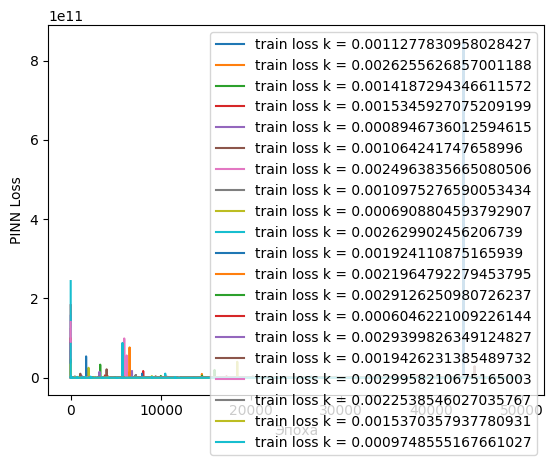

In [42]:
start_time = time.time()
study.optimize(objective, n_trials=20) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

поиск по первым эпохам

In [12]:
def objective(trial):
    k = trial.suggest_float('k', 5e-2, 1.2)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(1_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

            torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
            lambda_ic=1.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем R^2
    r2_1 = r2_score(
        torch.tensor(data["S_bc1_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred1.detach().numpy()
        )
    r2_2 = r2_score(
        torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred2.detach().numpy()
        )

    # Берем среднее
    r2 = np.mean([r2_1,r2_2])

    return r2

In [13]:
study = optuna.create_study(study_name="find_optimal_k", direction="maximize")

[I 2026-05-24 20:51:02,003] A new study created in memory with name: find_optimal_k


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 24328683520.000 | k = 1.054
Epoch 100 | Loss: 423083.062 | k = 1.054
Epoch 200 | Loss: 1214336.625 | k = 1.054
Epoch 300 | Loss: 27419754.000 | k = 1.054
Epoch 400 | Loss: 21050734.000 | k = 1.054
Epoch 500 | Loss: 1030795392.000 | k = 1.054
Epoch 600 | Loss: 460567.688 | k = 1.054
Epoch 700 | Loss: 416914.219 | k = 1.054
Epoch 800 | Loss: 425325.625 | k = 1.054
Epoch 900 | Loss: 416908.500 | k = 1.054


[I 2026-05-24 20:51:12,464] Trial 0 finished with value: -18.377721786499023 and parameters: {'k': 1.053601184490537}. Best is trial 0 with value: -18.377721786499023.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 3797089280.000 | k = 0.774
Epoch 100 | Loss: 303218.500 | k = 0.774
Epoch 200 | Loss: 296098.531 | k = 0.774
Epoch 300 | Loss: 2015589.125 | k = 0.774
Epoch 400 | Loss: 708366.312 | k = 0.774
Epoch 500 | Loss: 348100.094 | k = 0.774
Epoch 600 | Loss: 4121859.000 | k = 0.774
Epoch 700 | Loss: 291401.656 | k = 0.774
Epoch 800 | Loss: 291335.750 | k = 0.774
Epoch 900 | Loss: 291333.719 | k = 0.774


[I 2026-05-24 20:51:21,972] Trial 1 finished with value: -11.071290016174316 and parameters: {'k': 0.7735805904430638}. Best is trial 1 with value: -11.071290016174316.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 195361152.000 | k = 0.267
Epoch 100 | Loss: 144674.031 | k = 0.267
Epoch 200 | Loss: 2359832.750 | k = 0.267
Epoch 300 | Loss: 141144.453 | k = 0.267
Epoch 400 | Loss: 133633.891 | k = 0.267
Epoch 500 | Loss: 148806.484 | k = 0.267
Epoch 600 | Loss: 1152547.375 | k = 0.267
Epoch 700 | Loss: 132690.469 | k = 0.267
Epoch 800 | Loss: 132661.859 | k = 0.267
Epoch 900 | Loss: 132659.531 | k = 0.267


...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 31896051712.000 | k = 0.921
Epoch 100 | Loss: 390365.219 | k = 0.921
Epoch 200 | Loss: 360766.469 | k = 0.921
Epoch 300 | Loss: 1163994.750 | k = 0.921
Epoch 400 | Loss: 37283444.000 | k = 0.921
Epoch 500 | Loss: 361190.906 | k = 0.921
Epoch 600 | Loss: 355533.438 | k = 0.921
Epoch 700 | Loss: 355531.062 | k = 0.921
Epoch 800 | Loss: 355529.344 | k = 0.921
Epoch 900 | Loss: 355526.969 | k = 0.921


[I 2026-05-24 20:52:29,476] Trial 8 finished with value: -14.653108596801758 and parameters: {'k': 0.9212258944329391}. Best is trial 2 with value: -4.082536697387695.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 561075840.000 | k = 0.992
Epoch 100 | Loss: 8923733.000 | k = 0.992
Epoch 200 | Loss: 401390.844 | k = 0.992
Epoch 300 | Loss: 400505.531 | k = 0.992
Epoch 400 | Loss: 1261146.500 | k = 0.992
Epoch 500 | Loss: 1203148.375 | k = 0.992
Epoch 600 | Loss: 103547160.000 | k = 0.992
Epoch 700 | Loss: 387784.031 | k = 0.992
Epoch 800 | Loss: 387746.906 | k = 0.992
Epoch 900 | Loss: 387742.250 | k = 0.992


[I 2026-05-24 20:52:39,318] Trial 9 finished with value: -16.572816848754883 and parameters: {'k': 0.9915451019341821}. Best is trial 2 with value: -4.082536697387695.


Лучший k: 0.2674744507660731
Лучший R^2: -4.082536697387695
Время выполнения поиска оптимального параметра: 96.49 секунд


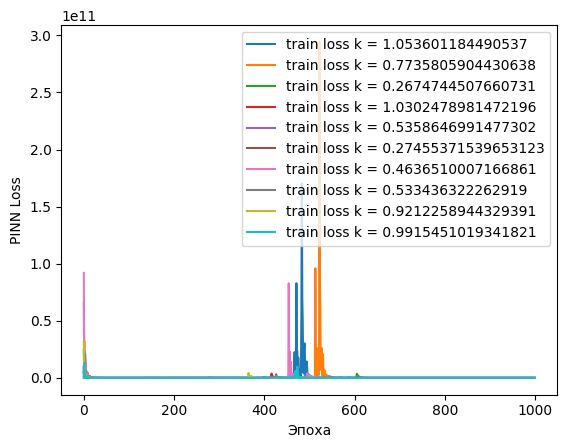

In [14]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

# ODE45

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Задание параметров системы
v = 0.001       # Скорость переноса
k = 0.5       # Коэффициент кинетики
S_max = 10.0  # Максимальное значение S
L = 10.0      # Длина расчетной области по z
T_max = 5.0   # Максимальное время моделирования

# 2. Пространственная сетка
Nz = 100                      # Количество точек по пространству
z = np.linspace(0, L, Nz)     # Сетка по z
dz = z[1] - z[0]              # Шаг сетки

# 3. Граничное и начальное условия
S_bound = 5.0                 # Значение S на левой границе (z = 0)
S0 = np.zeros(Nz)             # Начальное распределение S(z) при t = 0
S0[0] = S_bound               # Согласование границы

# 4. Правая часть системы ОДУ (метод прямых)
def pde_system(t, S):
    dSdt = np.zeros_like(S)
    
    # Граничное условие на левой границе z = 0 (фиксированное значение)
    dSdt[0] = 0 
    
    # Направленная разность назад для производной dS/dz (аппроксимация первого порядка)
    # dS/dz ≈ (S[i] - S[i-1]) / dz
    dS_dz = (S[1:] - S[:-1]) / dz
    
    # Вычисление dS/dt для внутренних и граничной правой точек
    dSdt[1:] = -v * dS_dz + k * (S_max - S[1:])
    
    return dSdt
start_time = time.time()
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

# 5. Решение системы аналогом ode45 (RK45)
t_span = (0, T_max)
t_eval = np.linspace(0, T_max, 100) # Точки времени, в которых сохраняем ответ

sol = solve_ivp(pde_system, t_span, S0, method='RK45', t_eval=t_eval)
execution_time = time.time() - start_time

# 6. Визуализация результатов
plt.figure(figsize=(10, 6))
# Построим профили S(z) для нескольких моментов времени
for i in range(0, len(sol.t), 20):
    plt.plot(z, sol.y[:, i], label=f't = {sol.t[i]:.1f}')

plt.title('Эволюция профиля $S(z, t)$')
plt.xlabel('Пространство (z)')
plt.ylabel('Концентрация (S)')
plt.grid(True)
plt.legend()
plt.show()

mse

In [43]:
import torch.nn.functional as F

In [44]:
def objective(trial):
    k = trial.suggest_float('k', 5e-4, 3e-3)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(40_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем mse
    mse = F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred2.detach())


    return mse

In [45]:
study = optuna.create_study(study_name="find_optimal_k", direction="minimize")

[I 2026-05-22 16:06:18,798] A new study created in memory with name: find_optimal_k


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 61546852352.000 | k = 0.003
Epoch 100 | Loss: 47004840.000 | k = 0.003
Epoch 200 | Loss: 10083198.000 | k = 0.003
Epoch 300 | Loss: 96565.398 | k = 0.003
Epoch 400 | Loss: 52567656.000 | k = 0.003
Epoch 500 | Loss: 100704.117 | k = 0.003
Epoch 600 | Loss: 174944.875 | k = 0.003
Epoch 700 | Loss: 1202050.625 | k = 0.003
Epoch 800 | Loss: 102590.469 | k = 0.003
Epoch 900 | Loss: 96336.680 | k = 0.003
Epoch 1000 | Loss: 96337.219 | k = 0.003
Epoch 1100 | Loss: 592270.062 | k = 0.003
Epoch 1200 | Loss: 178495.141 | k = 0.003
Epoch 1300 | Loss: 96296.859 | k = 0.003
Epoch 1400 | Loss: 96301.031 | k = 0.003
Epoch 1500 | Loss: 984967.812 | k = 0.003
Epoch 1600 | Loss: 100376.984 | k = 0.003
Epoch 1700 | Loss: 96318.688 | k = 0.003
Epoch 1800 | Loss: 2235083.250 | k = 0.003
Epoch 1900 | Loss: 615193.938 | k = 0.003
Epoch 2000 | Loss: 96329.977 | k = 0.003
Epoch 2100 | Loss: 97963.008 | k = 0.003
Epoch 2200 | Loss: 96398.734 | k = 0.003
Ep

[I 2026-05-22 16:10:39,739] Trial 0 finished with value: 11663.599609375 and parameters: {'k': 0.0028502750381729494}. Best is trial 0 with value: 11663.599609375.


Лучший k: 0.0028502750381729494
Лучший MSE: 11663.599609375
Время выполнения поиска оптимального параметра: 246.74 секунд


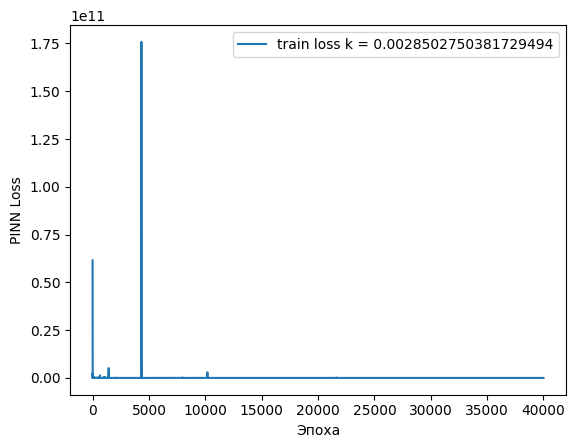

In [46]:
start_time = time.time()
study.optimize(objective, n_trials=1) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший MSE:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")